# Kernel PCA — Comprehensive Study Notes
**Topic:** Advanced Machine Learning → Dimensionality Reduction  
**Prepared for:** Group Assessment  

---

## 1. Background: Why PCA Falls Short

**PCA (Principal Component Analysis)** is a *linear* technique. It projects high-dimensional data into a lower-dimensional space by finding directions (principal components) that **maximise variance**.

- Works well when data lies roughly on a straight line or flat plane.
- **Fails when data is nonlinear** — e.g., shaped like circles, spirals, or moons — because linear subspaces may be inefficient for such datasets.
- If the data is embedded on a manifold, we should capture *that* structure, not just linear variance.

> **Key insight:** There are circumstances where linear subspaces are not good enough — they may not adequately represent the underlying manifold, which may have some other non-linear structure.

---
## 2. What is Kernel PCA (KPCA)?

**Kernel Principal Component Analysis (KPCA)** is a technique used in machine learning for **nonlinear dimensionality reduction**.

- KPCA applies a **nonlinear mapping function** to the data *before* applying PCA, allowing it to capture more complex and nonlinear relationships between data points.
- It "unfolds" the data into a space where circles look like lines — making nonlinear patterns linearly separable.
- A **kernel** is a clever way of measuring similarity between data points.
- Instead of explicitly moving data into higher dimensions (expensive), we just **calculate how similar points are** — this is the famous **kernel trick**.
- It is conceptually similar to Support Vector Machines (SVMs).

### Advantages over Standard PCA
- Handles **nonlinear relationships** between input features.
- Useful for tasks such as **image recognition** and **speech recognition**.
- Projecting to a higher dimension can simplify data that is not linearly separable:

$$
(x_1, x_2) \mapsto (x_1, x_2, x_1^2 + x_2^2)
$$

In higher dimensions, linear relationships are sufficient. If you map a decision boundary back into the lower-dimensional space, you get a **non-linear decision boundary** — so you can use all the tools from linear analysis and get non-linear results in the original space. This forms the foundation for KPCA.

---
## 3. How Kernel PCA Works — Step by Step

1. **Start with the data** (maybe circles, spirals, or moons).
2. **Use a kernel function** (like RBF) to calculate similarity between every pair of points.
3. The kernel **represents the data in a hidden higher-dimensional space**.
4. In that hidden space, **PCA is applied** → the data becomes separable/reducible.
5. **Project the data back** into fewer dimensions (like 2D) for visualisation or preprocessing.

**Formally — KPCA Recipe:**

| Step | Action |
|------|--------|
| 1 | Pick a kernel function $k(x_i, x_j)$ |
| 2 | Calculate the kernel matrix $K$ |
| 3 | Centre the kernel matrix: $\tilde{K} = K - 2\left(\frac{1}{d}\right)K + \left(\frac{1}{d}\right)K\left(\frac{1}{d}\right)$ |
| 4 | Solve the eigenproblem: $\tilde{K}\alpha_i = \lambda_i \alpha_i$ |
| 5 | Project data to each new dimension $j$: $y_j = \sum_{i=1}^{d} \alpha_{ij}\, k(x_i, x)$ for $j = 1, 2, \ldots m$ |

---
## 4. The Kernel Trick — Mathematical Foundation

Standard PCA relies on **eigenvectors of the sample covariance matrix** $XX^T$. This can be represented in the new feature space by the **kernel matrix** $K$, composed of dot products:

$$
K = \phi(X)\, \phi(X)^T
$$

**Consequently:** We can implicitly model any nonlinear transformation $\phi(x)$. The only requirement is that we can calculate the dot product $\phi(x_i)^T \phi(x_j)$ **efficiently** — without ever computing $\phi$ explicitly.

### The Kernel Matrix $K$
Contains **all pairwise evaluations** of the dot product:

$$
K = \begin{bmatrix}
k(x_1,x_1) & k(x_1,x_2) & \cdots & k(x_1,x_d) \\
k(x_2,x_1) & k(x_2,x_2) & \cdots & k(x_2,x_d) \\
\vdots & & & \vdots \\
k(x_n,x_1) & k(x_n,x_2) & \cdots & k(x_n,x_d)
\end{bmatrix}
$$

### Scaling Comparison
| Method | Scales with |
|--------|--------------|
| Standard PCA's covariance matrix | Number of input dimensions $n$ |
| KPCA's kernel matrix | Number of data points $d$ (training set size) |

> KPCA's kernel matrix scales with the number of datapoints because we are calculating the dot products of datapoints against all the others. That is why it scales with $d$ — the number of datapoints in the training set.

---
## 5. Kernel Functions

**What kernel function to use?** We look at some sort of *decreasing function of distance* in the original feature space. Typically we use the **Gaussian (RBF) kernel**, which lets us figure out what the dot products are in the high-dimensional space.

| Kernel | Formula | Notes |
|--------|---------|-------|
| **Linear** | $k(x_i, x_j) = x_i^T x_j$ | Equivalent to standard PCA |
| **Polynomial** | $k(x_i, x_j) = (x_i^T x_j + c)^d$ | Captures polynomial interactions |
| **Gaussian / RBF** | $k(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$ | Most commonly used; controlled by $\gamma$ |
| **Sigmoid** | $k(x_i, x_j) = \tanh(\alpha x_i^T x_j + c)$ | Similar to neural network activation |

The **$\gamma$ parameter** in the RBF kernel controls how tightly the kernel fits the data — higher $\gamma$ = tighter fit.

---
## 6. Practical Example in Python (sklearn)

### Step 1 — Generate a nonlinear dataset (moons)

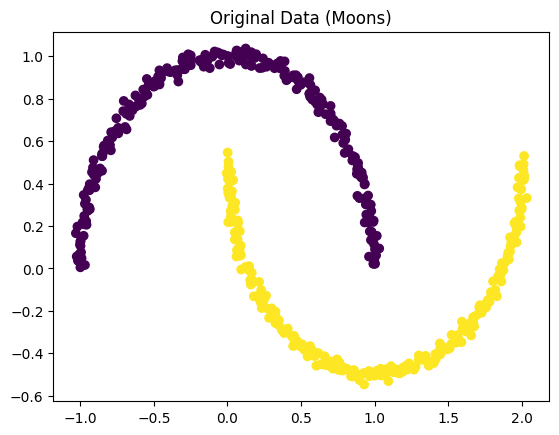

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.02, random_state=417)

plt.title("Original Data (Moons)")
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()
# The two classes form crescent/moon shapes — clearly nonlinear

### Step 2 — Apply standard PCA (observe it fails)

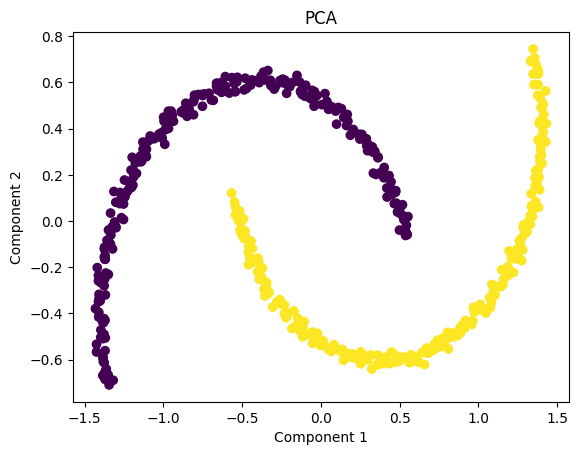

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.title("PCA")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()
# Classes still overlap — PCA cannot separate nonlinear data

### Step 3 — Apply Kernel PCA with RBF kernel (gamma=15)

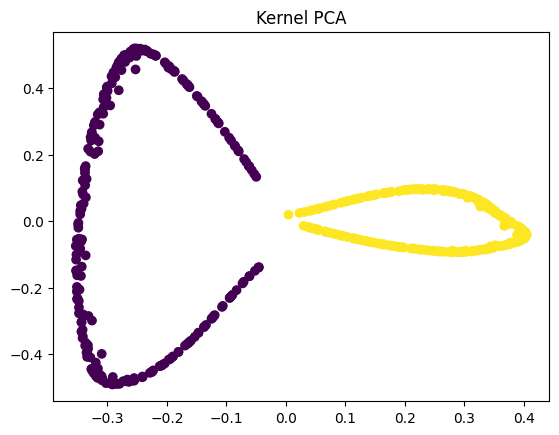

In [3]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X)

plt.title("Kernel PCA")
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.show()
# The two classes are now clearly separated — KPCA successfully unfolds the nonlinear structure

---
## 7. Key Hyperparameters in sklearn's KernelPCA

| Parameter | Description |
|-----------|-------------|
| `kernel` | `'rbf'`, `'poly'`, `'linear'`, `'sigmoid'`, `'cosine'` |
| `gamma` | Controls RBF/poly kernel width; higher = tighter fit |
| `n_components` | Number of dimensions to project to |
| `degree` | Degree for polynomial kernel |
| `fit_inverse_transform` | If `True`, enables reconstruction back to original space |

---
## 8. Limitations of Kernel PCA *(from additional research)*

These are important points **not fully covered in the LMS** but relevant for the assessment:

1. **Computational cost:** The kernel matrix $K$ is $n \times n$ — for large datasets this becomes memory-intensive and slow. Standard PCA scales with dimensions; KPCA scales with data points.
2. **No direct inverse transform:** Unlike standard PCA, you cannot trivially reconstruct original data from KPCA components (unless `fit_inverse_transform=True` is set, which uses an approximation).
3. **Kernel & hyperparameter selection:** Choosing the right kernel and $\gamma$ requires domain knowledge or cross-validation. A poor choice can give worse results than standard PCA.
4. **Interpretability:** The principal components in the kernel feature space are hard to interpret — they don't correspond to original features.
5. **Out-of-sample extension:** Projecting *new* data points requires storing the entire training kernel matrix (unlike PCA which just needs the component vectors).

---
## 9. Summary

| | PCA | Kernel PCA |
|---|---|---|
| Type | Linear | Nonlinear |
| Works on | Linearly structured data | Nonlinear manifolds |
| Uses kernel trick | ✗ | ✓ |
| Covariance matrix size | $n \times n$ (features) | $d \times d$ (samples) |
| Interpretability | High | Low |
| Scalability | Good | Limited for large $d$ |

> **One-line definition:** KPCA takes training data, maps it into a higher-dimensional space where PCA is performed — which in the original data space would be represented as a *nonlinear projection or transformation* of the data.